In [1]:
# needed to do a git checkout  v3.21.0
import healpy as hp
%matplotlib inline
import matplotlib.pylab as plt
import numpy as np
import pickle
from lsst.resources import ResourcePath
from rubin_nights.lfa_data import get_scheduler_snapshot

In [2]:
#uri = "https://s3.cp.lsst.org/rubinobs-lfa-cp/Scheduler:1/Scheduler:1/2026/07/13/Scheduler:1_Scheduler:1_2026-07-14T10:07:20.305.p"
#resource = get_scheduler_snapshot(uri, at_usdf=False)

In [3]:
def get_scheduler_snapshot(uri: str, at_usdf: bool = True) -> tuple[Any, Any, Any]:
    if at_usdf:
        uri = usdf_lfa(uri, bucket="s3://lfa@")
        os.environ["LSST_DISABLE_BUCKET_VALIDATION"] = "1"
    resource = ResourcePath(uri).read()
    # unpickle
    scheduler, conditions, add_targets = pickle.loads(resource)
    return scheduler, conditions, add_targets


In [4]:
#pickle_file = "snap_attempt.pkl"
#scheduler, conditions, add_targets = get_scheduler_snapshot(pickle_file, at_usdf=False)
with open("snap_attempt.pkl", 'rb') as file:
    ack = pickle.load(file)
    

In [5]:
scheduler, conditions, add_targets = pickle.loads(ack)


In [8]:
rew = scheduler.survey_lists[5][3].calc_reward_function(conditions)

In [10]:
scheduler.survey_lists[4][3].basis_functions

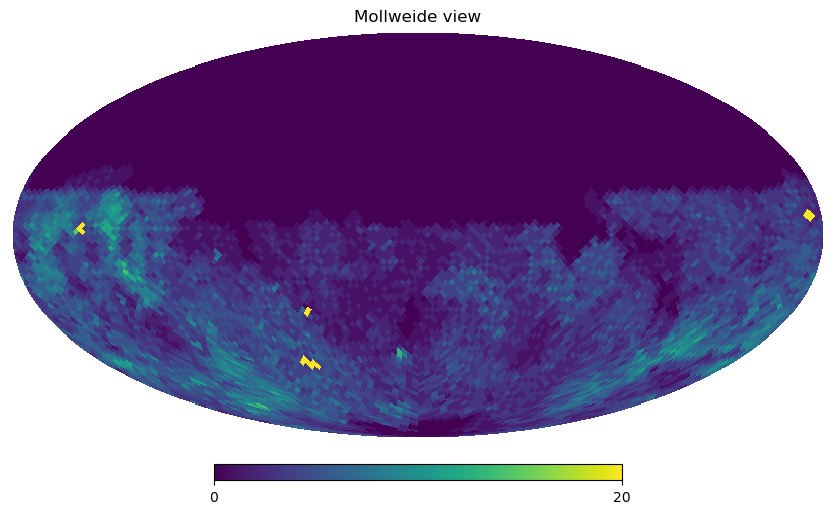

In [17]:
hp.mollview(scheduler.survey_lists[4][3].basis_functions[3].survey_features["N_obs"].feature, max=20)

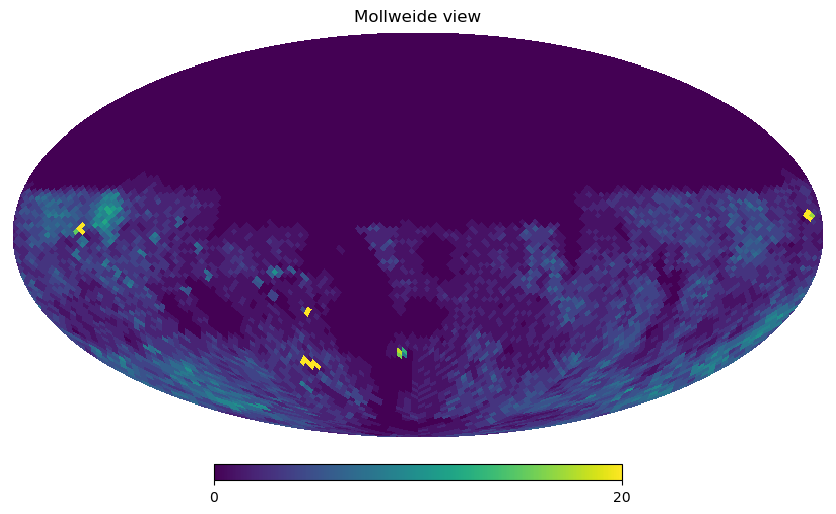

In [18]:
hp.mollview(scheduler.survey_lists[4][3].basis_functions[2].survey_features["N_obs"].feature, max=20)

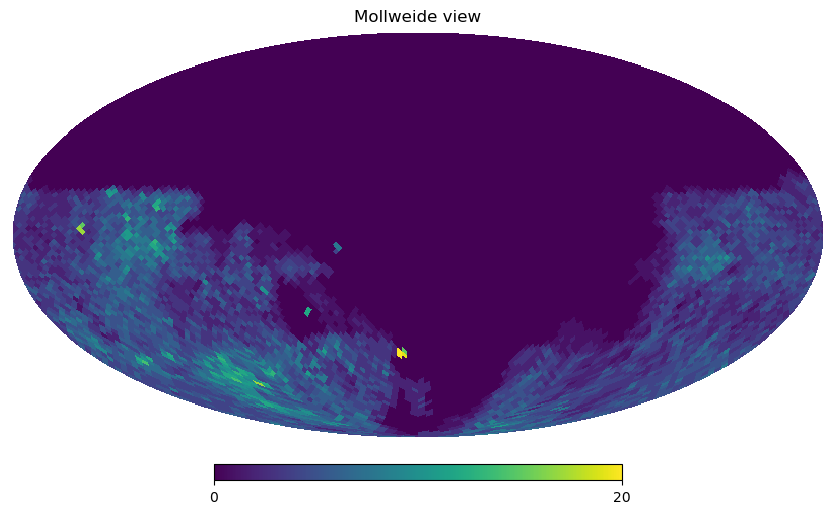

In [19]:
hp.mollview(scheduler.survey_lists[4][5].basis_functions[3].survey_features["N_obs"].feature, max=20)

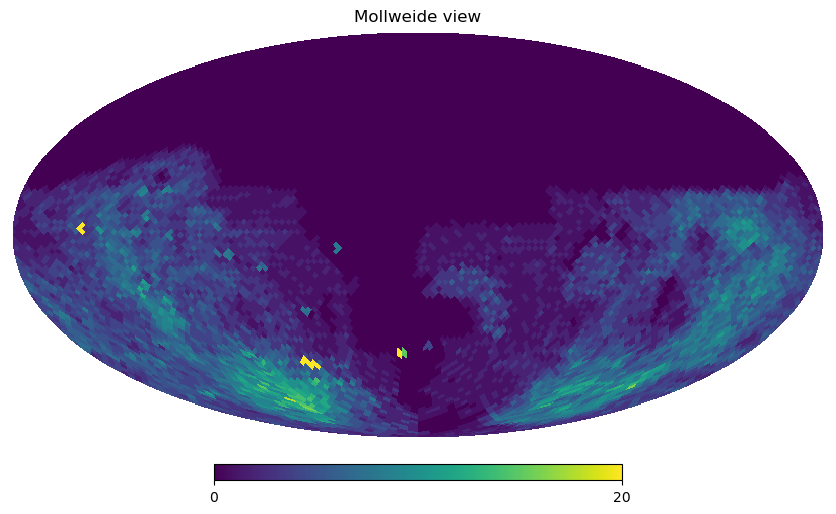

In [22]:
hp.mollview(scheduler.survey_lists[4][5].basis_functions[2].survey_features["N_obs"].feature, max=20)